In [1]:
import pandas as pd
import spacy
from gliner import GLiNER
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import ast

# spacy for dependency parsing - finds grammatical relationships between words
nlp = spacy.load("en_core_web_sm")

# GLiNER - zero-shot NER, can detect entity types without training data
# same model used in the KG comparison lab
gliner_model = GLiNER.from_pretrained("urchade/gliner_mediumv2.1")

print("spaCy loaded")
print("GLiNER loaded")

c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\huggingface_hub\utils\_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
c:\Users\amirh\Documents\projects\youtube-intelligence-engine\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but yo

spaCy loaded
GLiNER loaded


In [2]:
df = pd.read_csv("../data/processed/comments_enriched.csv")

# entities got saved as a string in the csv (lists can't go directly into csv)
# convert it back into an actual python list here
df["entities_parsed"] = df["entities"].apply(ast.literal_eval)

# count how many entities each comment has
df["entity_count"] = df["entities_parsed"].apply(len)

# only using top 500 entity-rich comments for the graph
# running this on all 27k would make the graph way too messy to read
top_entity_comments = df.sort_values("entity_count", ascending=False).head(500)

print("Comments selected for knowledge graph:", len(top_entity_comments))
print("\nEntity count distribution in selection:")
print(top_entity_comments["entity_count"].describe())
print("\nSample comment with most entities:")
print(top_entity_comments.iloc[0]["text"][:200])
print("Entities:", top_entity_comments.iloc[0]["entities_parsed"])

Comments selected for knowledge graph: 500

Entity count distribution in selection:
count    500.000000
mean       6.224000
std        3.224068
min        4.000000
25%        5.000000
50%        5.000000
75%        7.000000
max       45.000000
Name: entity_count, dtype: float64

Sample comment with most entities:
Companies criticized are (YouTube, Google, Ubisoft, Roblox, TikTok, Meta, Disney, Rovio, Paramount, Netflix, Twitter, Amazon, Nvidia, OpenAI, Discord, Microsoft, Nintendo, Electronic Arts, Spotify, Hu
Entities: [('YouTube', 'ORG'), ('Google', 'ORG'), ('Ubisoft', 'GPE'), ('Roblox', 'GPE'), ('TikTok', 'ORG'), ('Meta', 'ORG'), ('Disney', 'ORG'), ('Rovio', 'ORG'), ('Paramount', 'ORG'), ('Netflix', 'ORG'), ('Twitter', 'ORG'), ('Amazon', 'ORG'), ('Nvidia', 'ORG'), ('Discord', 'ORG'), ('Microsoft', 'ORG'), ('Nintendo', 'ORG'), ('Electronic Arts', 'ORG'), ('Spotify', 'ORG'), ('Hulu', 'ORG'), ('Tesla', 'ORG'), ('Epic Games', 'ORG'), ('HP', 'ORG'), ('Grammarly', 'PERSON'), ('Samsung', '

In [3]:
def find_entity_span(doc, entity_text):
    """
    Locate an entity string inside a spaCy parsed document.
    Returns the token span if found, None otherwise.
    Same approach as the GLiNER+spaCy lab.
    """
    entity_lower = entity_text.lower()
    for token in doc:
        if token.text.lower() == entity_lower.split()[0]:
            # check if multi-word entity matches starting here
            span_end = token.i + len(entity_text.split())
            if span_end <= len(doc):
                span_text = doc[token.i:span_end].text.lower()
                if span_text == entity_lower:
                    return doc[token.i:span_end]
    return None


def extract_relations(text, entities):
    """
    Extract subject-relation-object triplets using dependency parsing.
    Looks for verbs connecting two known entities in the same sentence.
    """
    doc = nlp(text)
    triplets = []
    
    entity_texts = [e[0] for e in entities]
    
    for sent in doc.sents:
        # find which entities appear in this sentence
        sent_entities = [e for e in entity_texts if e.lower() in sent.text.lower()]
        
        if len(sent_entities) < 2:
            continue
        
        # find the main verb in the sentence (the relation)
        main_verb = None
        for token in sent:
            if token.pos_ == "VERB" and token.dep_ in ("ROOT", "ccomp"):
                main_verb = token.lemma_
                break
        
        if not main_verb:
            main_verb = "mentioned_with"  # fallback relation
        
        # connect first entity found to others in same sentence
        for i in range(len(sent_entities) - 1):
            triplets.append((sent_entities[i], main_verb, sent_entities[i+1]))
    
    return triplets


# test on sample comment
sample_text = top_entity_comments.iloc[5]["text"]
sample_entities = top_entity_comments.iloc[5]["entities_parsed"]

print("Sample text:", sample_text[:200])
print("\nExtracted triplets:")
test_triplets = extract_relations(sample_text, sample_entities)
for t in test_triplets[:10]:
    print(f"  {t[0]} --[{t[1]}]--> {t[2]}")

Sample text: Debe ser algo normal en las generaciones de siempre admirar al pasado e inspirarse, pero lo ví con mucha mas fuerza estos ultimos años que literalmente las nuevas generaciones preferian la ropa, la mu

Extracted triplets:
  Debe ser algo --[mentioned_with]--> en las generaciones de siempre admirar al pasado e
  en las generaciones de siempre admirar al pasado e --[mentioned_with]--> pero lo ví con mucha
  pero lo ví con mucha --[mentioned_with]--> mas fuerza estos
  mas fuerza estos --[mentioned_with]--> la musica
  la musica --[mentioned_with]--> las peliculas de los 2000s
  las peliculas de los 2000s --[mentioned_with]--> para escapar del presente
  para escapar del presente --[mentioned_with]--> Que
  Que --[mentioned_with]--> mejor antes"
  mejor antes" --[mentioned_with]--> en la época
  Que --[llevó]--> cosas asi


In [4]:
# quick language check - English text should have mostly common English words
# this is a lightweight heuristic, not a full language detector
ENGLISH_MARKERS = {"the", "is", "are", "and", "will", "this", "that", "ai", "people"}

def looks_english(text):
    words = set(str(text).lower().split())
    overlap = len(words & ENGLISH_MARKERS)
    return overlap >= 2

top_entity_comments["is_english"] = top_entity_comments["text"].apply(looks_english)

english_subset = top_entity_comments[top_entity_comments["is_english"]]

print(f"English comments in top 500: {len(english_subset)} / {len(top_entity_comments)}")
print(f"Non-English filtered out: {len(top_entity_comments) - len(english_subset)}")

# test relation extraction on a real English sample
sample_row = english_subset.iloc[2]
print("\nSample text:", sample_row["text"][:200])
print("\nExtracted triplets:")
test_triplets = extract_relations(sample_row["text"], sample_row["entities_parsed"])
for t in test_triplets[:10]:
    print(f"  {t[0]} --[{t[1]}]--> {t[2]}")

English comments in top 500: 476 / 500
Non-English filtered out: 24

Sample text: The answer is simple, there will be no plan. Politicians are too spineless right not too formulate one, and the wealthy don't care about any of us. The timing of this coincides with multiple impending

Extracted triplets:
  the United States --[mentioned_with]--> Neurolink
  the United States --[survive]--> America
  AI --[fail]--> the United States
  the United States --[fail]--> America
  China --[gobble]--> Australia
  Australia --[gobble]--> New Zealand
  New Zealand --[gobble]--> US
  US --[gobble]--> India
  AI --[ally]--> China
  China --[ally]--> India


In [5]:
KG = nx.DiGraph()

all_triplets = []

for _, row in english_subset.iterrows():
    triplets = extract_relations(row["text"], row["entities_parsed"])
    all_triplets.extend(triplets)
    for subj, rel, obj in triplets:
        KG.add_edge(subj, obj, relation=rel)

print(f"Total triplets extracted: {len(all_triplets)}")
print(f"Graph nodes (unique entities): {KG.number_of_nodes()}")
print(f"Graph edges (relationships): {KG.number_of_edges()}")

# show most connected entities - these are the "hubs" of discussion
degree_centrality = dict(KG.degree())
top_connected = sorted(degree_centrality.items(), key=lambda x: -x[1])[:15]

print("\nTop 15 most connected entities:")
for entity, degree in top_connected:
    print(f"  {entity}: {degree} connections")

Total triplets extracted: 2183
Graph nodes (unique entities): 1113
Graph edges (relationships): 1612

Top 15 most connected entities:
  AI: 457 connections
  Google: 56 connections
  US: 52 connections
  LLM: 40 connections
  ChatGPT: 32 connections
  Gemini: 31 connections
  Microsoft: 31 connections
  Claude: 30 connections
  YouTube: 30 connections
  AGI: 29 connections
  UBI: 24 connections
  automation: 23 connections
  OpenAI: 22 connections
  India: 21 connections
  China: 20 connections


In [6]:
def query_knowledge_graph(graph, entity_node):
    """
    Print all outward relationships from a given entity.
    Same query interface as the lab's REBEL/GLiNER notebooks.
    """
    if entity_node not in graph:
        print(f"'{entity_node}' not found in graph")
        return
    
    print(f"\nRelationships for '{entity_node}':")
    for _, target, data in graph.out_edges(entity_node, data=True):
        print(f"  {entity_node} --[{data['relation']}]--> {target}")
    
    # also show incoming relationships
    for source, _, data in graph.in_edges(entity_node, data=True):
        print(f"  {source} --[{data['relation']}]--> {entity_node}")


# query the most interesting entities
query_knowledge_graph(KG, "OpenAI")
query_knowledge_graph(KG, "Google")


Relationships for 'OpenAI':
  OpenAI --[bet]--> Anthropic
  OpenAI --[hate]--> Altman
  OpenAI --[get]--> AI
  OpenAI --[’]--> ChatGPT
  OpenAI --[have]--> Gemini
  OpenAI --[’]--> Musk
  OpenAI --[publish]--> DeepMind
  VC --[mentioned_with]--> OpenAI
  GEMINI --[take]--> OpenAI
  AI --[happen]--> OpenAI
  Sam Altman --[hate]--> OpenAI
  Microsoft --[discourage]--> OpenAI
  OpenAI/Gemini --[have]--> OpenAI
  Facebook --[’]--> OpenAI
  OpenResearch --[do]--> OpenAI
  Optimus --[’]--> OpenAI
  Sora --[do]--> OpenAI
  AGI --[sincerley]--> OpenAI
  Nvidia --[go]--> OpenAI
  AI Scaling Laws --[publish]--> OpenAI
  Google --[get]--> OpenAI
  LLM --[want]--> OpenAI

Relationships for 'Google':
  Google --[mentioned_with]--> Sundar Pichai
  Google --[wipe]--> TB Google
  Google --[use]--> Sketchup
  Google --[mentioned_with]--> TRACE
  Google --[build]--> Meta
  Google --[mentioned_with]--> TSMC
  Google --[anticipate]--> Microsoft
  Google --[make]--> AI
  Google --[make]--> YouTube
  Googl

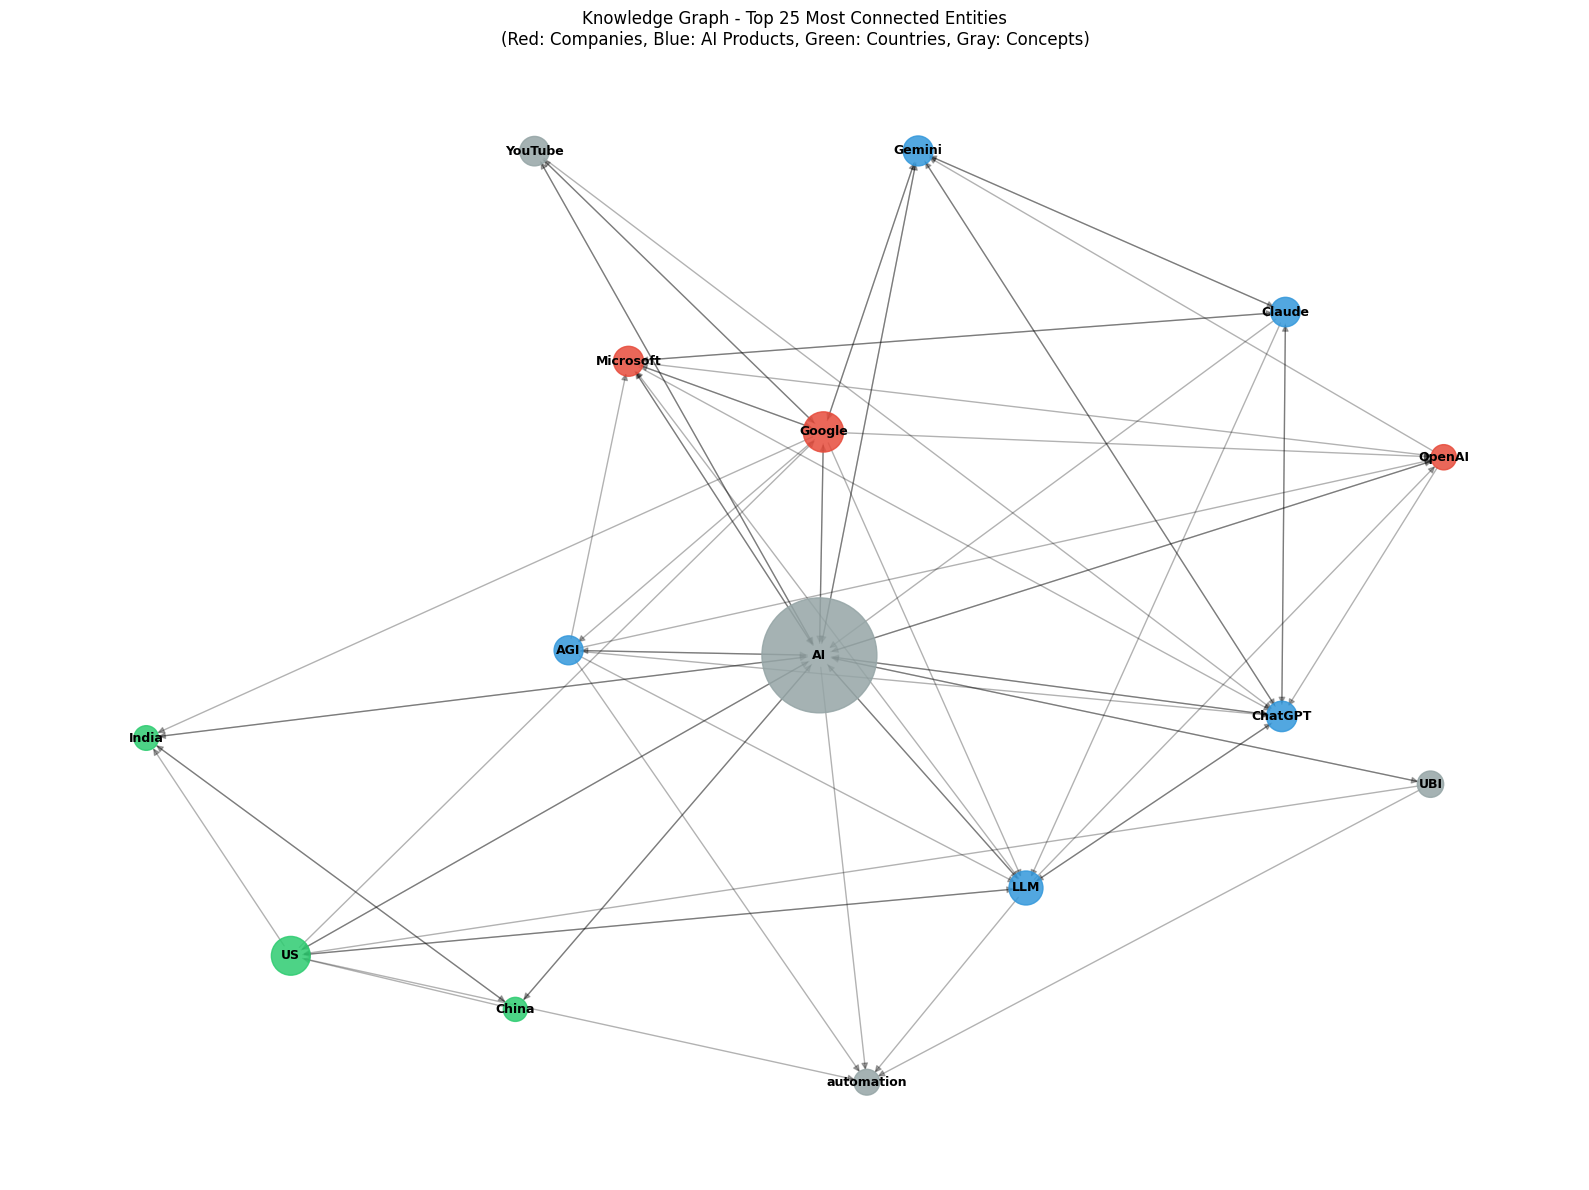

Graph saved.


In [7]:
# build a subgraph with only highly connected entities for readability
top_n = 25
top_entities = [e for e, d in top_connected[:top_n]]

subgraph = KG.subgraph(top_entities).copy()

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(subgraph, k=2, seed=42)

# color nodes by rough category
def get_color(node):
    companies = ["Google", "Microsoft", "OpenAI", "Meta", "Amazon", "Nvidia", "Apple"]
    products = ["ChatGPT", "Gemini", "Claude", "AGI", "LLM"]
    if node in companies:
        return "#e74c3c"
    elif node in products:
        return "#3498db"
    elif node in ["US", "India", "China"]:
        return "#2ecc71"
    else:
        return "#95a5a6"

node_colors = [get_color(n) for n in subgraph.nodes()]
node_sizes = [degree_centrality.get(n, 1) * 15 for n in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(subgraph, pos, alpha=0.3, arrows=True, arrowsize=10)
nx.draw_networkx_labels(subgraph, pos, font_size=9, font_weight="bold")

plt.title("Knowledge Graph - Top 25 Most Connected Entities\n(Red: Companies, Blue: AI Products, Green: Countries, Gray: Concepts)", fontsize=12)
plt.axis("off")
plt.tight_layout()
plt.savefig("../data/processed/knowledge_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph saved.")

In [8]:
# save the most interesting triplets as a CSV for the report
interesting_triplets = pd.DataFrame(all_triplets, columns=["subject", "relation", "object"])

# filter to triplets involving top entities only - removes most noise
top_set = set(top_entities)
clean_triplets = interesting_triplets[
    interesting_triplets["subject"].isin(top_set) | 
    interesting_triplets["object"].isin(top_set)
]

clean_triplets.to_csv("../data/processed/knowledge_graph_triplets.csv", index=False)

print(f"Total triplets: {len(all_triplets)}")
print(f"Triplets involving top 25 entities: {len(clean_triplets)}")
print(f"\nMost common relations:")
print(Counter(interesting_triplets["relation"]).most_common(10))

print(f"\nGraph saved to: data/processed/knowledge_graph.png")
print(f"Triplets saved to: data/processed/knowledge_graph_triplets.csv")

Total triplets: 2183
Triplets involving top 25 entities: 1316

Most common relations:
[('mentioned_with', 424), ('have', 119), ('use', 73), ('be', 60), ('go', 45), ('do', 38), ('think', 38), ('make', 35), ('see', 35), ('replace', 34)]

Graph saved to: data/processed/knowledge_graph.png
Triplets saved to: data/processed/knowledge_graph_triplets.csv


# Knowledge Graph Extraction — Entity Relationships

Applies dependency-parsing-based relation extraction (spaCy + GLiNER, from CSCI370 Lab) 
to the 500 most entity-rich comments in the dataset, surfacing relationships between 
companies, AI products, countries, and concepts that simple entity counting cannot show.

**Method:** For each sentence containing two or more known entities, the main verb of 
the sentence is extracted as the "relation" connecting them, forming (subject, relation, 
object) triplets — the same approach demonstrated in the REBEL/GLiNER comparison lab, 
applied here to noisy real-world social media comments instead of clean corpus text.

## Findings

- 2,183 triplets extracted from 476 English-language comments, forming a graph of 1,113 unique entities and 1,612 relationships
- AI is the dominant hub with 457 connections, as expected given the dataset's topic
- Google, Microsoft, and OpenAI are the most-discussed companies; ChatGPT, Gemini, and Claude the most-discussed products; US, India, and China the dominant geopolitical angle
- "replace" appears among the top 10 relations (34 instances), directly reflecting the dataset's central theme of AI replacing jobs

**Limitation:** Dependency-parse-based relation extraction is a rule-based heuristic, not a trained model. It produces interpretable but noisy results — many relations default to the generic "mentioned_with" fallback when no clear verb connects two entities in a sentence, and some extracted relations (e.g. "Google --[google]--> Denny") are extraction artifacts rather than genuine relationships. A small number of non-English comments were filtered out (24 of 500) since the English-only spaCy model produced nonsensical parses on them. This trade-off — zero training cost and full interpretability versus precision — mirrors the comparison made in the REBEL vs GLiNER vs FLAN-T5 lab between rule-based, zero-shot, and fine-tuned approaches to knowledge extraction.